In [5]:
!pip install celltypist

In [7]:
import scanpy as sc

In [9]:
import celltypist
from celltypist import models

In [10]:
models.download_models(force_update = True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in /root/.celltypist/data/models
💾 Downloading model [1/61]: Immune_All_Low.pkl
💾 Downloading model [2/61]: Immune_All_High.pkl
💾 Downloading model [3/61]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/61]: Adult_Human_MTG.pkl
💾 Downloading model [6/61]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/61]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/61]: Adult_Human_Skin.pkl
💾 Downloading model [9/61]: Adult_Human_Vascular.pkl
💾 Downloading model [10/61]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/61]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/61]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/61]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/61]: Adult_cHSPCs_Illumina.pkl
💾 Downloading model [15/61]: Adult_cHSPCs_Ultima.pkl
💾 Downloadi

In [11]:
models.models_description()

👉 Detailed model information can be found at `https://www.celltypist.org/models`


,model,description
0,Immune_All_Low.pkl,immune sub-populations combined from 20 tissue...
1,Immune_All_High.pkl,immune populations combined from 20 tissues of...
2,Adult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types from C...
3,Adult_CynomolgusMacaque_Hippocampus.pkl,cell types from the hippocampus of adult cynom...
4,Adult_Human_MTG.pkl,cell types and subtypes (10x-based) from the a...
...,...,...
56,Nuclei_Lung_Airway.pkl,cell populations from snRNA-seq of five locati...
57,PaediatricAdult_COVID19_Airway.pkl,cell types in the airway of paediatric and adu...
58,PaediatricAdult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types of pae...
59,Pan_Fetal_Human.pkl,stromal and immune populations from the human ...


In [12]:
model = models.Model.load(model = 'Immune_All_Low.pkl')

In [13]:
# 1) Leer el loom
adata = sc.read_loom("counts.loom", sparse=True, obs_names="CellID", var_names="Gene")

# 2) Asegurar nombres únicos
adata.var_names_make_unique()
adata.obs_names_make_unique()

# 3) Normalizar counts crudos
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [14]:
predictions = celltypist.annotate(adata, model = 'Immune_All_Low.pkl', majority_voting = True)

🔬 Input data has 5312 cells and 20441 genes
🔗 Matching reference genes in the model
🧬 4797 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [15]:
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
CellID,,,
CACCAAAAGCCGATCT,Cycling T cells,0,Cycling T cells
CTAGACAAGCTACCGT,Cycling T cells,0,Cycling T cells
GTAATCGAGCGATTAG,Cycling T cells,0,Cycling T cells
ATAGACCCACCAGCCA,Cycling T cells,0,Cycling T cells
ATCGTCCTCATTGACA,Cycling T cells,0,Cycling T cells
...,...,...,...
AGGGTCCAGGTACCTC,Tem/Effector helper T cells,62,Tem/Effector helper T cells
TGCAGATGTGTAGTGG,Tem/Effector helper T cells,44,Tem/Effector helper T cells
AAGTCGTCATGCGGCT,Tcm/Naive helper T cells,112,Tem/Effector helper T cells


In [16]:
# Get an `AnnData` with predicted labels embedded into the cell metadata columns
adata = predictions.to_adata()

In [17]:
adata.obs

,nGene,nUMI,predicted_labels,over_clustering,majority_voting,conf_score
CellID,,,,,,
CACCAAAAGCCGATCT,7432,71786.0,Cycling T cells,0,Cycling T cells,0.874528
CTAGACAAGCTACCGT,7205,69302.0,Cycling T cells,0,Cycling T cells,0.985814
GTAATCGAGCGATTAG,7511,74444.0,Cycling T cells,0,Cycling T cells,0.945125
ATAGACCCACCAGCCA,7093,58862.0,Cycling T cells,0,Cycling T cells,0.876703
ATCGTCCTCATTGACA,6681,55123.0,Cycling T cells,0,Cycling T cells,0.970524
...,...,...,...,...,...,...
AGGGTCCAGGTACCTC,1256,4365.0,Tem/Effector helper T cells,62,Tem/Effector helper T cells,0.246394
TGCAGATGTGTAGTGG,1542,4264.0,Tem/Effector helper T cells,44,Tem/Effector helper T cells,0.892301
AAGTCGTCATGCGGCT,1585,5868.0,Tcm/Naive helper T cells,112,Tem/Effector helper T cells,0.178099


In [18]:
sc.tl.umap(adata)

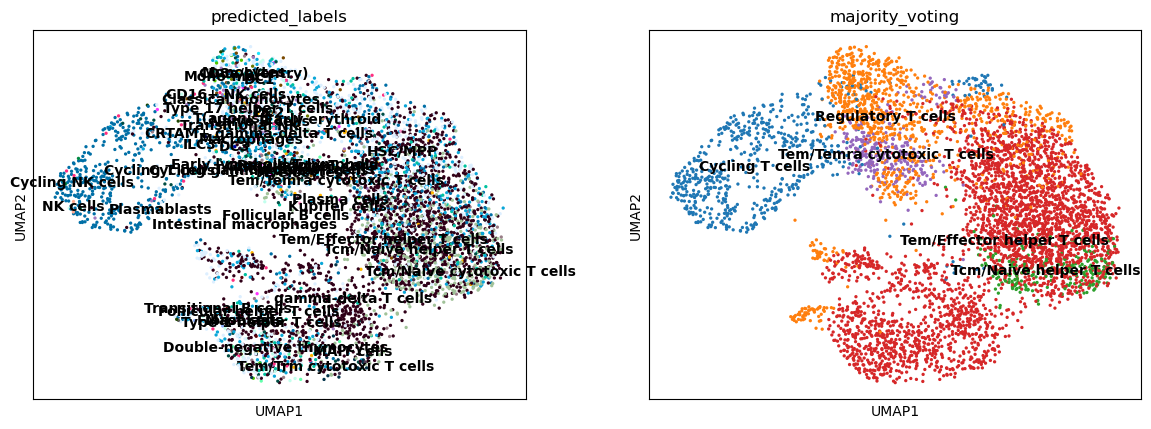

In [19]:
sc.pl.umap(adata, color = ['predicted_labels', 'majority_voting'], legend_loc = 'on data')

In [21]:
meta = adata.obs[["predicted_labels", "majority_voting", "conf_score"]].copy()
meta.to_csv("celltypist_metadata.csv")